In [1]:
%pip install -r requirements.txt

In [2]:
import os
import pandas as pd
import numpy as np

from IPython.display import display, HTML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import  LatentDirichletAllocation, NMF
import spacy
import re
import pyLDAvis
import pyLDAvis.lda_model
import matplotlib.pyplot as plt
import textwrap
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from langdetect import detect, DetectorFactory
from bertopic import BERTopic
import umap
import hdbscan
from wordcloud import WordCloud
import seaborn as sns

from utils import *

<frozen importlib._bootstrap>:488: DeprecationWarning:

builtin type SwigPyPacked has no __module__ attribute

<frozen importlib._bootstrap>:488: DeprecationWarning:

builtin type SwigPyObject has no __module__ attribute



In [3]:
STOPWORDS = [x.strip() for x in open('data/stop_word_fr.txt').readlines()]

In [4]:
ref = pd.read_csv("archelect_search.csv")[['id', 'contexte-election', 'contexte-tour', 'titulaire-soutien', 'titulaire-liste']]

ref["titulaire-soutien"] = ref["titulaire-soutien"].str.split(";").str[0]

C:\Users\flori\AppData\Local\Temp\ipykernel_3776\2891533250.py:1: DtypeWarning:

Columns (0: departement-nom, 1: departement-insee, 2: identifiant de circonscription, 3: pdf, 4: suppleant-nom, 5: suppleant-prenom, 6: suppleant-sexe, 7: suppleant-age, 8: suppleant-age-calcule, 9: suppleant-age-tranche, 10: suppleant-profession, 11: suppleant-mandat-en-cours, 12: suppleant-mandat-passe, 13: suppleant-associations, 14: suppleant-autres-statuts, 15: suppleant-soutien, 16: suppleant-liste, 17: suppleant-decorations) have mixed types. Specify dtype option on import or set low_memory=False.



In [5]:
TEXT_DIR_1981 = "1981/legislatives"
TEXT_DIR_1988 = "1988/legislatives"

df_1981 = load_texts_from_dir(TEXT_DIR_1981)
df_1988 = load_texts_from_dir(TEXT_DIR_1988)

df_1981["year"] = 1981
df_1988["year"] = 1988

df = pd.concat([df_1981, df_1988], axis=0, ignore_index=True)

Nombre de documents chargés : 3182
Nombre de documents chargés : 3628


In [6]:
df2 = df.merge(ref, how = "left", on="id")

In [7]:
pd.set_option('display.max_rows', 10)

print("\n--------------- First 5 rows of the DataFrame ---------------")

# List of columns to display
columns_to_show = ['id', 'contexte-election', 'contexte-tour', 'titulaire-soutien', 'titulaire-liste']

# Display only these columns
display(df2[columns_to_show].head())


--------------- First 5 rows of the DataFrame ---------------


,id,contexte-election,contexte-tour,titulaire-soutien,titulaire-liste
0,EL134_L_1981_06_001_01_1_PF_01,législatives,1.0,Parti socialiste unifié,non mentionné
1,EL134_L_1981_06_001_01_1_PF_02,législatives,1.0,Parti communiste français,Union de la gauche
2,EL134_L_1981_06_001_01_1_PF_03,législatives,1.0,Parti socialiste,non mentionné
3,EL134_L_1981_06_001_01_1_PF_04,législatives,1.0,Fédération des socialistes démocrates,non mentionné
4,EL134_L_1981_06_001_01_1_PF_05,législatives,1.0,Rassemblement pour la République,Union pour la nouvelle majorité


In [8]:
###Keep only manifestos from the first round
df_first_round = df2[df2['contexte-tour'] == 1].copy().reset_index(drop=True)

print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [9]:
print(f"Professions au 1er tour :{len(df_first_round)}")

Professions au 1er tour :5153


In [10]:
top_partis = {
    "Parti communiste français",
    "Parti socialiste",
    "Lutte ouvrière",
    "Parti socialiste unifié",
    "Rassemblement pour la République",
    "Union pour la démocratie française",
    "Mouvement des radicaux de gauche",
    "Front national",
    "Ligue communiste révolutionnaire",
    "Parti des forces nouvelles"
}

df_first_round["parti"] = df_first_round["titulaire-soutien"].apply(lambda x: x if x in top_partis else "Autre")

In [11]:
partis_ref = {
    "Parti communiste français": ["parti communiste français", "pcf", "communistes", "communiste"],
    "Parti socialiste": ["parti socialiste", "ps", "socialistes"],
    "Lutte ouvrière": ["lutte ouvrière", "lo"],
    "Parti socialiste unifié": ["parti socialiste unifié", "psu"],
    "Rassemblement pour la République": ["rassemblement pour la république", "rpr"],
    "Union pour la démocratie française": ["union pour la démocratie française", "udf"],
    "Mouvement des radicaux de gauche": ["mouvement des radicaux de gauche", "mrg", "radicaux de gauche"],
    "Front national": ["front national", "fn"],
    "Ligue communiste révolutionnaire": ["ligue communiste révolutionnaire", "lcr"],
    "Parti des forces nouvelles": ["parti des forces nouvelles", "pfn"]
}

exemples = [
    "les socialistes ont gagné la circonscription",
    "un membre du front national",
    "une alliance RPR-UDF s'est formée",
    "un parti inconnu ou très éloigné" 
]

for ex in exemples:
    print(f"Texte: {ex} -> Partis détectés: {associer_partis_nlp_strict(ex, partis_ref)}")

Texte: les socialistes ont gagné la circonscription -> Partis détectés: Parti socialiste
Texte: un membre du front national -> Partis détectés: Front national
Texte: une alliance RPR-UDF s'est formée -> Partis détectés: Rassemblement pour la République
Texte: un parti inconnu ou très éloigné -> Partis détectés: None


In [12]:
df_first_round["lang"] = df_first_round["text"].apply(detect_lang)

df_first_round = df_first_round[df_first_round["lang"] == "fr"]

In [21]:
test = df_first_round[df_first_round["year"] == 1988]["parti"].unique()

In [22]:
test

<ArrowStringArray>
[                    'Front national',                              'Autre',
   'Rassemblement pour la République',          'Parti communiste français',
 'Union pour la démocratie française',                   'Parti socialiste',
   'Mouvement des radicaux de gauche',         'Parti des forces nouvelles',
            'Parti socialiste unifié']
Length: 9, dtype: str

In [13]:
nlp = spacy.load("fr_core_news_sm", disable=["parser"])
df_first_round['lemmatized_text'] = [" ".join([token.lemma_ for token in doc]) for doc in nlp.pipe(df_first_round['text'])]
german_keywords = [
    "werden", "ist", "von", "und", "haben", "das", "nicht"
]

pattern = r"\b(" + "|".join(german_keywords) + r")\b"

df_german = df_first_round[df_first_round['lemmatized_text'].str.contains(pattern, case=False, regex=True)].reset_index(drop=True)

print(f"Number of texts containing German keywords: {len(df_german)}")

df_french = df_first_round[~df_first_round['lemmatized_text'].str.contains(pattern, case=False, regex=True)].reset_index(drop=True)
df_french.to_csv("df.txt",sep=";")

Number of texts containing German keywords: 128


In [14]:
print(f"Nombre de professions de foi restantes : {len(df_french)}")

Nombre de professions de foi restantes : 4982


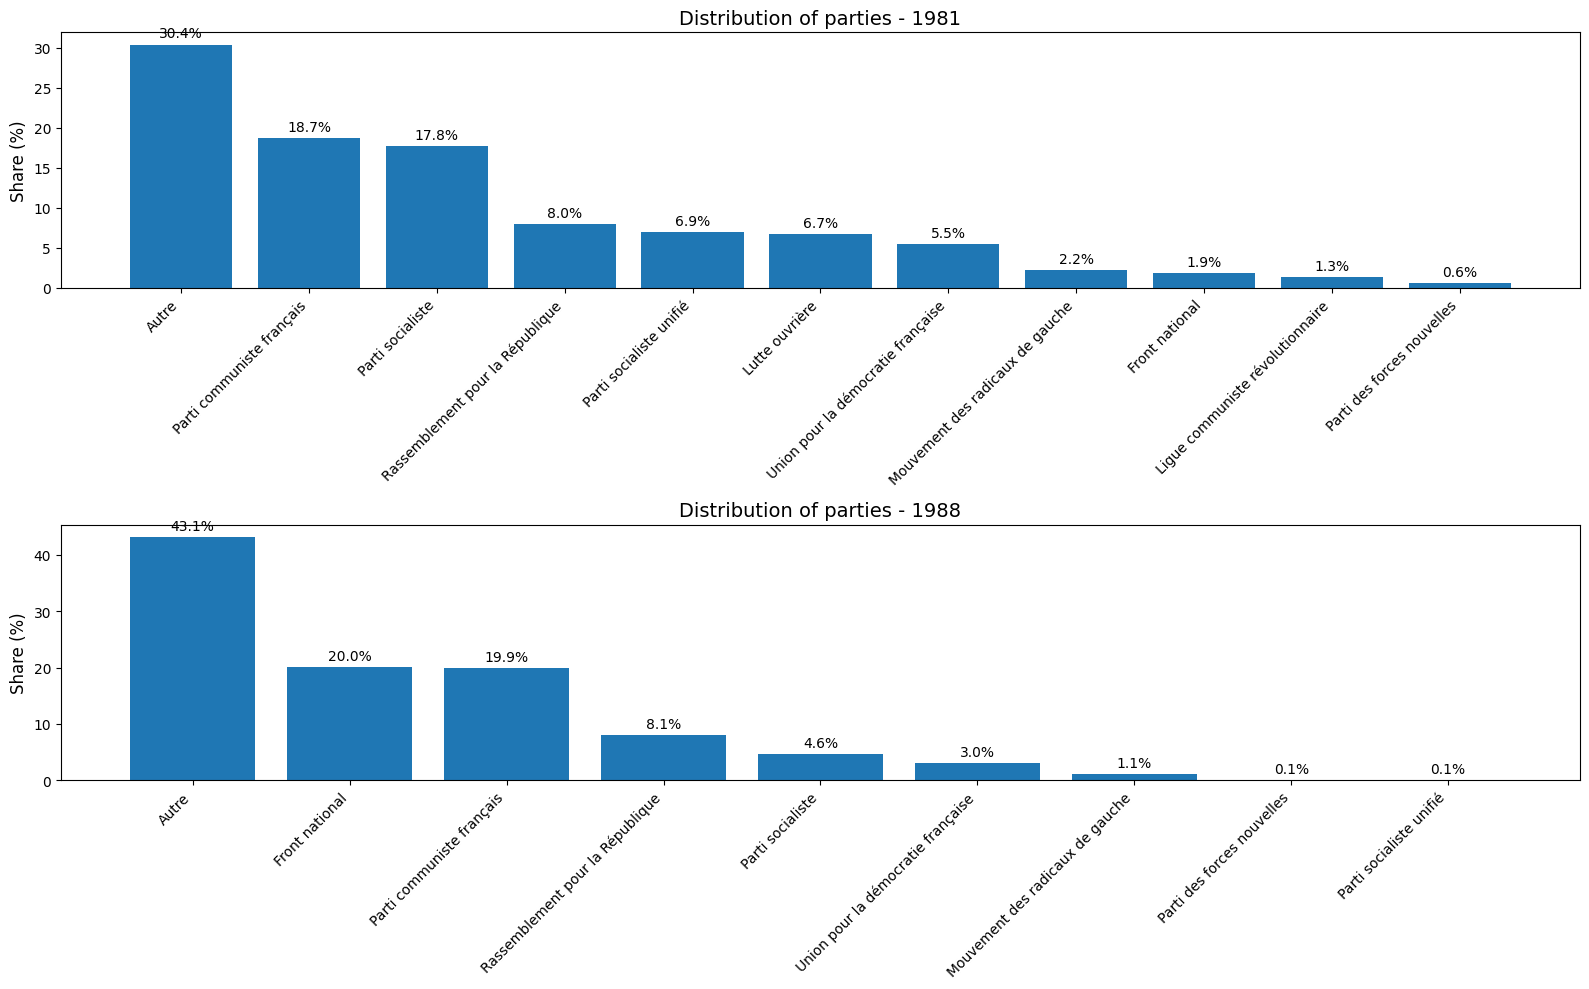

In [15]:
years = [1981, 1988]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for i, year in enumerate(years):
    counts = (
        df_french[df_french['year'] == year]["parti"]
        .value_counts()
        .reset_index()
    )
    counts.columns = ['Modality', 'Count']

    counts['Share'] = counts['Count'] / counts['Count'].sum()
    counts['Share (%)'] = (counts['Share'] * 100).round(2)

    ax = axes[i]
    bars = ax.bar(counts['Modality'], counts['Share (%)'])

    ax.set_ylabel('Share (%)', fontsize=12)
    ax.set_title(f'Distribution of parties - {year}', fontsize=14)
    ax.set_xticklabels(counts['Modality'], rotation=45, ha='right')

    ax.bar_label(bars, fmt='%.1f%%', padding=3)

fig.tight_layout()
fig.savefig('sorties/parti_distribution.png')
plt.show()

In [16]:
df = pd.read_csv("df.txt",sep=";").drop(columns=["Unnamed: 0","id","text","lang","contexte-election","contexte-tour","titulaire-liste"])

## 2. First transformations

In [17]:
df_1981 = df[df["year"] == 1981].copy()
df_1988 = df[df["year"] == 1988].copy()

docs_1981 = df_1981["lemmatized_text"].tolist()
docs_1988 = df_1988["lemmatized_text"].tolist()
docs = df["lemmatized_text"].tolist()

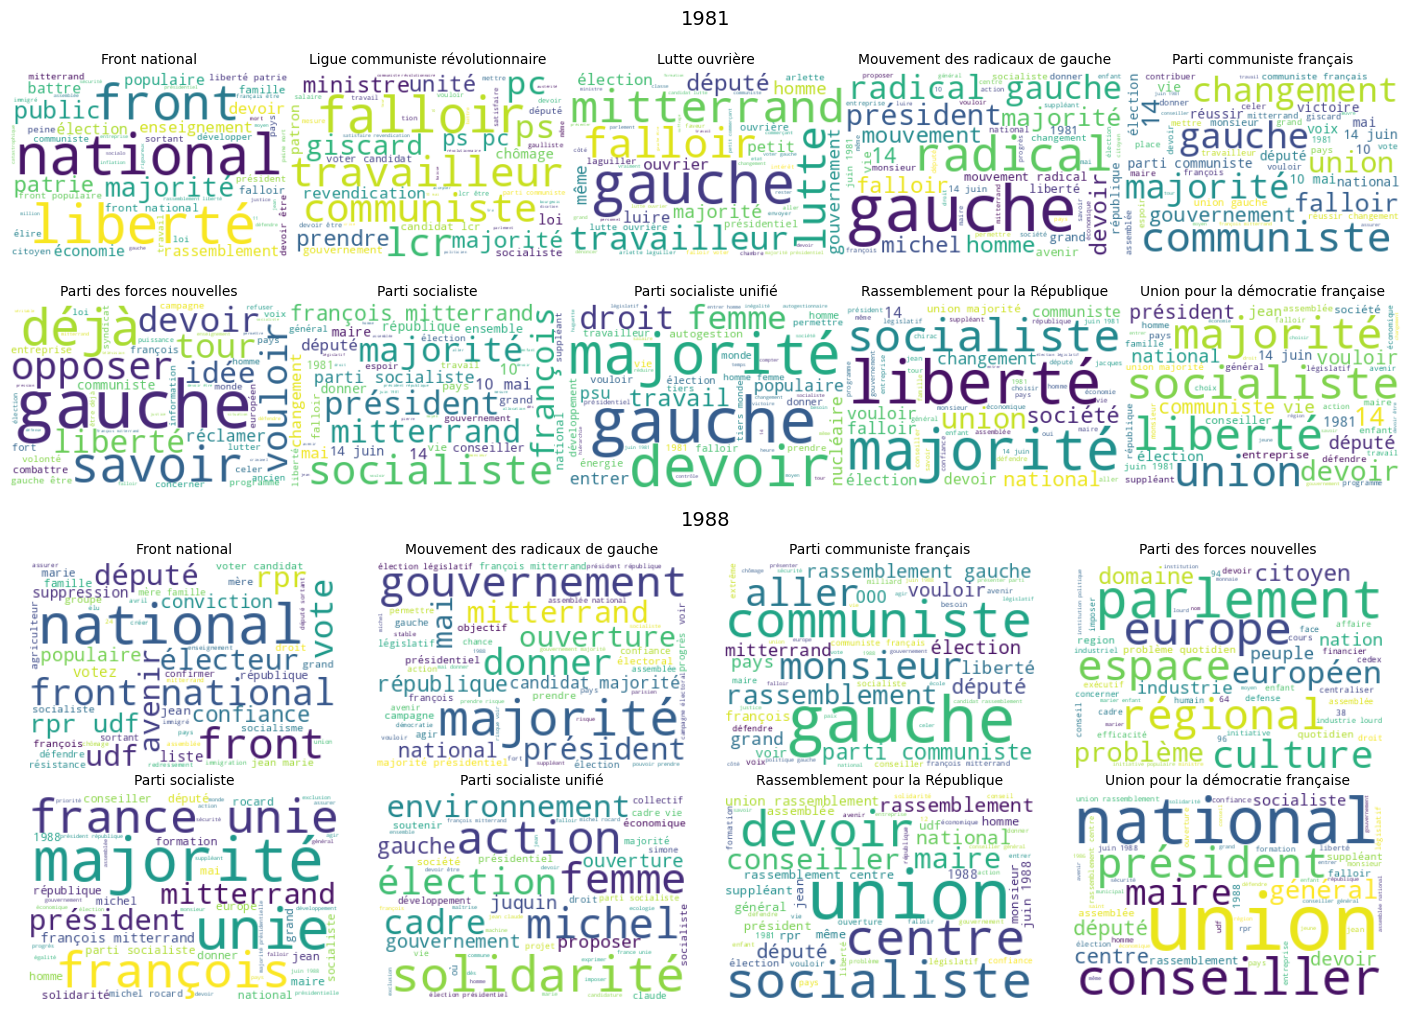

In [50]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import math
from sklearn.feature_extraction.text import CountVectorizer

# --- 1. Vectorisation ---
df_vectorizer = CountVectorizer(
    stop_words=STOPWORDS,
    min_df=0.005,
    max_df=0.7,
    ngram_range=(1, 2)
)

X = df_vectorizer.fit_transform(df["lemmatized_text"])
feature_names = df_vectorizer.get_feature_names_out()

# --- 2. Fonction pour créer BOW par année ---
def get_bow(df_year, X, feature_names):
    mask = df["year"] == df_year
    X_year = X[mask.values]  # Sparse matrix compatible avec boolean array
    df_year_subset = df[mask]
    df_bow = pd.DataFrame(X_year.toarray(), columns=feature_names)
    df_bow["parti"] = df_year_subset["parti"].values
    bow_parti = df_bow.groupby("parti").sum()
    return bow_parti

# --- 3. Création des BOWs par année ---
bow_81 = get_bow(1981, X, feature_names)
bow_88 = get_bow(1988, X, feature_names)

# --- 4. Catégories globales ---
categories = sorted([c for c in df["parti"].unique() if c != "Autre"])

# --- 5. Fonction WordCloud par année ---
def plot_year(ax, bow_parti, title):
    ax.axis('off')
    
    # Titre principal de l'année
    ax.text(0.5, 1.02, title, transform=ax.transAxes,
            ha='center', va='bottom', fontsize=14)
    
    # Liste des partis présents pour cette année
    present_partis = [cat for cat in categories if cat in bow_parti.index]
    
    n = len(present_partis)
    n_rows = 2
    n_cols = math.ceil(n / n_rows)
    
    top_margin = 0.05   # espace réservé pour titre principal
    row_gap = 0.05      # espace entre lignes internes
    
    usable_height = (1 - top_margin) - row_gap
    h = usable_height / n_rows
    
    for i, cat in enumerate(present_partis):
        row = i // n_cols
        col = i % n_cols
        
        x0 = col / n_cols
        y0 = 1 - top_margin - (row + 1) * h - row * row_gap
        w = 1 / n_cols
        
        subax = ax.inset_axes([x0, y0, w, h])
        
        freqs = bow_parti.loc[cat]
        freqs = freqs[freqs > 0]
        
        if len(freqs) > 0:
            wc = WordCloud(
                width=300, height=200,
                background_color='white',
                colormap='viridis',
                max_words=50
            ).generate_from_frequencies(freqs.to_dict())
            
            subax.imshow(wc, interpolation='bilinear')
        
        # Toujours afficher le titre du parti
        subax.axis('off')
        subax.set_title(cat, fontsize=10)

# --- 6. Figure principale ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)

plot_year(axes[0], bow_81, "1981")
plot_year(axes[1], bow_88, "1988")

plt.savefig("sorties/bag_81_88.png")
plt.show()

In [4]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    message="This process .* is multi-threaded, use of fork.*"
)

In [ ]:
from sentence_transformers import SentenceTransformer

sentence_model_minilm = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

emb = sentence_model_minilm.encode(docs, show_progress_bar=True)

np.save("embeddings.npy", emb)
#emb = np.load("embeddings.npy")

In [10]:
vectorizer_model = CountVectorizer(
    stop_words = STOPWORDS,
    min_df=0.005,
    max_df=0.7,
    ngram_range=(1, 1)
)

In [ ]:
# ==== Coherence function ====
def compute_coherence(topic_model, docs):
    topics = [
        [word for word, _ in topic_model.get_topic(t)]
        for t in topic_model.get_topics().keys() if t != -1
    ]
    tokenized_docs = [doc.split() for doc in docs]
    dictionary = Dictionary(tokenized_docs)
    coherence_model = CoherenceModel(
        topics=topics,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    return coherence_model.get_coherence()


# ==== Topic Diversity ====
def compute_topic_diversity(topic_model, topk=10):
    topics = [
        [word for word, _ in topic_model.get_topic(t)[:topk]]
        for t in topic_model.get_topics().keys()
        if t != -1
    ]
    all_words = [word for topic in topics for word in topic]
    unique_words = set(all_words)
    diversity = len(unique_words) / len(all_words) if len(all_words) > 0 else 0
    return diversity


def build_topic_model(n_neighbors, n_components, min_cluster_size=10, min_dist=0.0):
    # UMAP
    umap_model = umap.UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
        min_dist=min_dist,
        metric='cosine',
        random_state=42
    )

    # HDBSCAN
    hdbscan_model = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=None,
        metric='euclidean',
        cluster_selection_method='eom'
    )

    # BERTopic
    return BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        top_n_words=10,
        nr_topics=None,  # on laisse BERTopic choisir
        verbose=False
    )



In [ ]:
from itertools import product

n_components_list = [2,3,4]
n_neighbors_list = range(10,20)
min_cluster_size_list = range(10,20)
min_dist_list = [0.1,0.3,0.5] 

results = []
models = {}

# ==== Grid Search ====
for n_comp, n_nbr, min_size, min_d in product(
        n_components_list, n_neighbors_list, min_cluster_size_list, min_dist_list):

    # Model    
    tm = build_topic_model(
        n_neighbors=n_nbr,
        n_components=n_comp,
        min_cluster_size=min_size,
        min_dist=min_d
    )
    
    # Fit & transform
    topics, probs = tm.fit_transform(docs, emb)
    
    # Récupérer le count du topic 0
    topic_info = tm.get_topic_info()
    topic0_count = topic_info.loc[topic_info['Topic'] == 0, 'Count'].values[0] if 0 in topic_info['Topic'].values else 0
    
    # Metrics
    coh = compute_coherence(tm, docs)
    div = compute_topic_diversity(tm)
    
    # Score
    score = coh * div
    
    # Save
    key = (n_comp, n_nbr, min_size, min_d)
    models[key] = (tm, topics, probs)
    
    results.append({
        "n_components": n_comp,
        "n_neighbors": n_nbr,
        "min_cluster_size": min_size,
        "min_dist": min_d,
        "coherence": coh,
        "diversity": div,
        "score": score,
        "n_topics": len(set(topics)) - (1 if -1 in topics else 0),  # nombre de topics réels
        "topic0_count": topic0_count
    })
    
    print(f"comp={n_comp}, neigh={n_nbr}, min_size={min_size}, min_dist={min_d} | "
          f"coh={coh:.4f}, div={div:.4f}, score={score:.4f}, n_topics={len(set(topics))}, "
          f"topic0_count={topic0_count}")

comp=5, neigh=18, min_size=18, min_dist=0.3 | coh=0.4066, div=0.8500, score=0.3456, n_topics=6, topic0_count=4716
comp=5, neigh=18, min_size=18, min_dist=0.5 | coh=0.3647, div=0.7833, score=0.2857, n_topics=7, topic0_count=4716
comp=5, neigh=18, min_size=19, min_dist=0.3 | coh=0.4066, div=0.8500, score=0.3456, n_topics=6, topic0_count=4716
comp=5, neigh=18, min_size=19, min_dist=0.5 | coh=0.3647, div=0.7833, score=0.2857, n_topics=7, topic0_count=4716
comp=5, neigh=19, min_size=18, min_dist=0.3 | coh=0.3647, div=0.7833, score=0.2857, n_topics=7, topic0_count=4716
comp=5, neigh=19, min_size=18, min_dist=0.5 | coh=0.3487, div=0.8000, score=0.2790, n_topics=7, topic0_count=4716
comp=5, neigh=19, min_size=19, min_dist=0.3 | coh=0.3647, div=0.7833, score=0.2857, n_topics=7, topic0_count=4716
comp=5, neigh=19, min_size=19, min_dist=0.5 | coh=0.3487, div=0.8000, score=0.2790, n_topics=7, topic0_count=4716
comp=7, neigh=18, min_size=18, min_dist=0.3 | coh=0.3701, div=0.7833, score=0.2899, n_to

In [ ]:
df_grid = pd.DataFrame(results)
df_grid = df_grid.sort_values(["coherence"], ascending=False).reset_index(drop=True)

print(df_grid.head(10))

df_grid.to_csv("grid_search_bertopic4.csv", sep=";", index=False)

   n_components  n_neighbors  min_cluster_size  min_dist  coherence  \
0             7           19                18       0.3   0.432184   
1             7           19                19       0.3   0.432184   
2            10           19                19       0.3   0.426228   
3            10           19                18       0.3   0.426228   
4             5           18                18       0.3   0.406571   
5             5           18                19       0.3   0.406571   
6             7           19                18       0.5   0.385524   
7             7           19                19       0.5   0.385524   
8             7           18                19       0.3   0.384330   
9            10           19                19       0.5   0.382522   

   diversity     score  n_topics  topic0_count  
0   0.866667  0.374559         6          4716  
1   0.866667  0.374559         6          4716  
2   0.866667  0.369397         6          4716  
3   0.866667  0.369397

### 3.2 BERTopic model

In [ ]:
comp = 4
neigh = 19
min_size = 19
min_dist = 0.3


umap_model = umap.UMAP(
    n_neighbors=neigh,
    n_components=comp,
    min_dist=min_dist,
    metric='cosine',
    random_state=42
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=min_size,
    metric='euclidean',
    cluster_selection_method='eom',
    min_samples=None
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    verbose=False,
    # calculate_probabilities=True,
    nr_topics=None
    )

topics, probs = topic_model.fit_transform(docs, emb)

In [65]:
for topic_id in topic_model.get_topic_info()["Topic"]:
    
    words = topic_model.get_topic(topic_id)
    words_str = " | ".join([word for word, _ in words])
    
    print(f"\n🧠 Topic {topic_id}")
    print(f"{words_str}")


🧠 Topic -1
upppa | atlantiques | bru | quiconqu | battre | pyrenee | porc | connaissent | environne | tal

🧠 Topic 0
majorit | communiste | falloir | homme | prsident | rpublique | changement | monsieur | donner | 14

🧠 Topic 1
accepter | triage | illusion | sortir | financier | production | dtruire | technologie | temps | celer

🧠 Topic 2
conviction | suppression | liste | redressement | fiscalist | lepen | payent | 4400000 | antisocialiste | absent

🧠 Topic 3
engager | degr | pourcent | chmeur | doubler | comptitivit | production | aller | million | 1992

🧠 Topic 4
lcr | travailleur | unit | revendication | patron | falloir | giscard | communiste | prendre | ministre

🧠 Topic 5
conviction | liste | suppression | penscience | fiscalist | 4400000 | gard | octroi | hgmonie | maternel


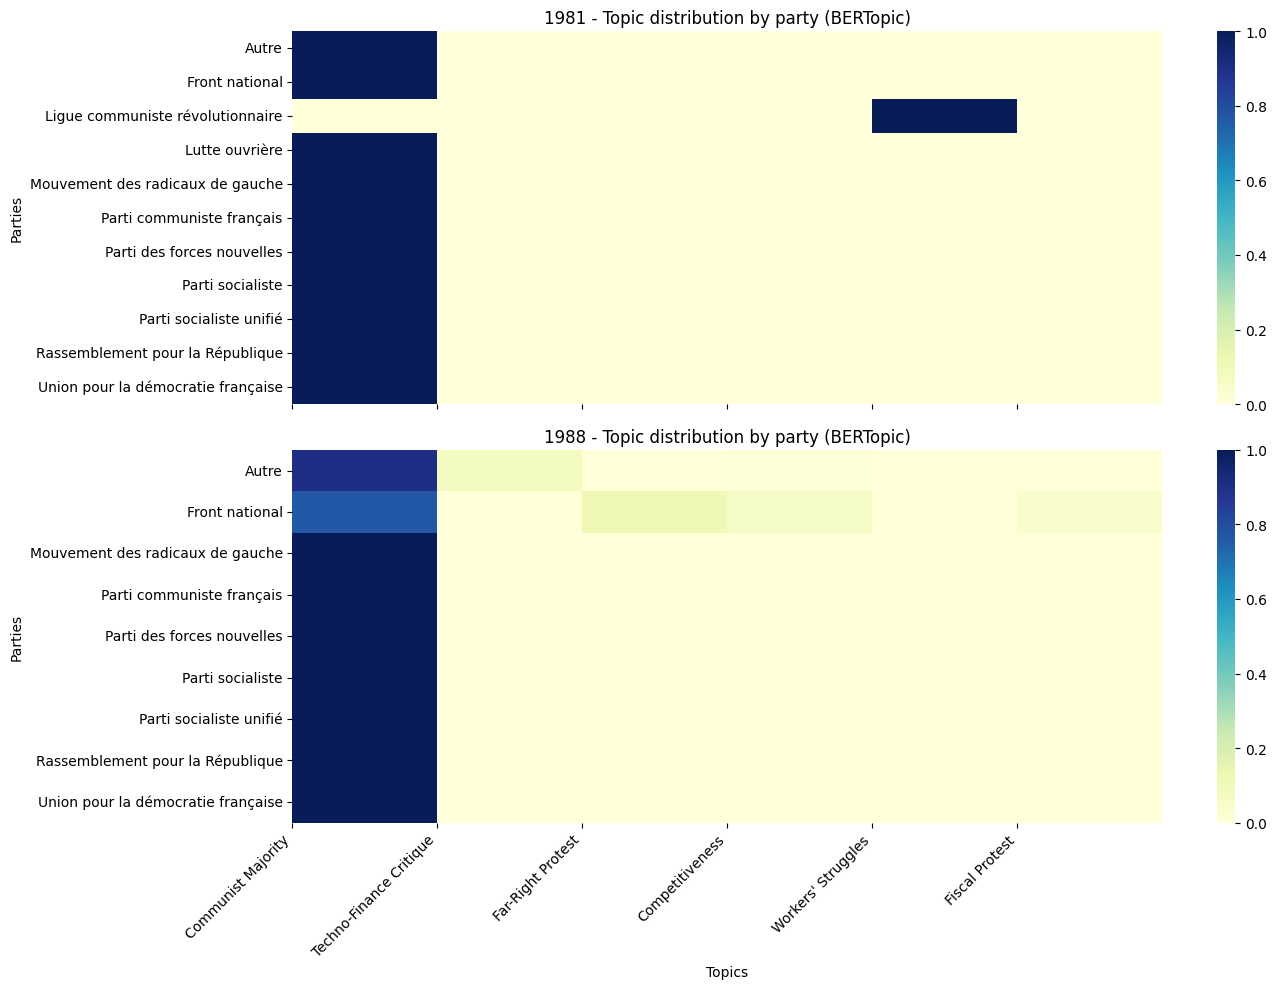

In [ ]:
# =========================
# DATAFRAME
# =========================
df2 = pd.DataFrame({
    "topic": topics,
    "parti": df["parti"],
    "annee": df["year"]
})

# enlever outliers
df2 = df2[df2["topic"] != -1]

# =========================
# DISTRIBUTION parti → topics
# =========================
counts = df2.groupby(["annee", "parti", "topic"]).size()

dist = counts.unstack(fill_value=0)

# ✅ NORMALISATION PAR PARTI (ligne = 1)
dist_norm = dist.div(dist.sum(axis=1), axis=0)

dist_81 = dist_norm.loc[1981]
dist_88 = dist_norm.loc[1988]

# =========================
# TITRES DES TOPICS
# =========================
topic_titles = [
    "Communist Majority",
    "Techno-Finance Critique",
    "Far-Right Protest",
    "Competitiveness",
    "Workers' Struggles",
    "Fiscal Protest"
    # ⚠️ adapte à ton nombre réel de topics
]

# =========================
# HEATMAPS
# =========================
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# 1981
sns.heatmap(dist_81, cmap="YlGnBu", ax=axes[0])
axes[0].set_title("1981 - Topic distribution by party (BERTopic)")
axes[0].set_ylabel("Parties")
axes[0].set_xlabel(None)

# 1988
sns.heatmap(dist_88, cmap="YlGnBu", ax=axes[1])
axes[1].set_title("1988 - Topic distribution by party (BERTopic)")
axes[1].set_ylabel("Parties")
axes[1].set_xlabel("Topics")

# ✅ labels propres
axes[1].set_xticks(np.arange(len(topic_titles)))
axes[1].set_xticklabels(topic_titles, rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 4. NMF

### 4.1 NMF Grid search

In [ ]:
# ==== Préparation ====
tokenized_docs = [doc.split() for doc in docs]
dictionary = Dictionary(tokenized_docs)

# ==== Coherence ====
def compute_coherence(topics):
    cm = CoherenceModel(
        topics=topics,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    return cm.get_coherence()

# ==== Diversity ====
def compute_topic_diversity(topics, topk=10):
    all_words = [word for topic in topics for word in topic[:topk]]
    return len(set(all_words)) / len(all_words) if all_words else 0

# ==== Extraction topics ====
def get_topics(model, feature_names, topk=10):
    topics = []
    for topic_weights in model.components_:
        idx = topic_weights.argsort()[-topk:][::-1]
        topics.append([feature_names[i] for i in idx])
    return topics

# ==== Grilles ====
n_topics_list = range(8,20)
ngram_range_list = [(1,1), (1,2)]

results = []
models = {}

# ==== Grid search ====
for n_topics, ngram_range in product(n_topics_list, ngram_range_list):

    # TF-IDF
    vectorizer = TfidfVectorizer(
        stop_words=STOPWORDS,
        ngram_range=ngram_range,
        min_df=0.005,
        max_df=0.7
    )

    X = vectorizer.fit_transform(docs)
    feature_names = vectorizer.get_feature_names_out()

    # NMF
    nmf_model = NMF(
        n_components=n_topics,
        random_state=42,
        init="nndsvd"
    )

    W = nmf_model.fit_transform(X)

    # Topics
    topics = get_topics(nmf_model, feature_names)

    # Metrics
    coh = compute_coherence(topics)
    div = compute_topic_diversity(topics)
    score = coh * div

    # Stockage
    key = (n_topics, ngram_range)
    models[key] = (nmf_model, vectorizer, W)

    results.append({
        "n_topics": n_topics,
        "ngram_range": ngram_range,
        "coherence": coh,
        "diversity": div,
        "score": score
    })

    print(f"topics={n_topics}, ngram={ngram_range} | "
          f"coh={coh:.4f}, div={div:.4f}, score={score:.4f}")

# ==== Résultats ====
df_grid = pd.DataFrame(results)
df_grid = df_grid.sort_values("score", ascending=False).reset_index(drop=True)

print("\nTop modèles :")
print(df_grid)

df_grid.to_csv("nmf_grid_search_simple.csv", sep=";", index=False)

topics=8, ngram=(1, 1) | coh=0.4834, div=0.9000, score=0.4351
topics=8, ngram=(1, 2) | coh=0.4995, div=0.8750, score=0.4371
topics=9, ngram=(1, 1) | coh=0.4838, div=0.8889, score=0.4301
topics=9, ngram=(1, 2) | coh=0.5058, div=0.8667, score=0.4384
topics=10, ngram=(1, 1) | coh=0.4864, div=0.8300, score=0.4037
topics=10, ngram=(1, 2) | coh=0.5191, div=0.8700, score=0.4516
topics=11, ngram=(1, 1) | coh=0.4968, div=0.8182, score=0.4065
topics=11, ngram=(1, 2) | coh=0.5309, div=0.8636, score=0.4585
topics=12, ngram=(1, 1) | coh=0.5017, div=0.8250, score=0.4139
topics=12, ngram=(1, 2) | coh=0.5501, div=0.8750, score=0.4813
topics=13, ngram=(1, 1) | coh=0.5102, div=0.8462, score=0.4317
topics=13, ngram=(1, 2) | coh=0.5601, div=0.8615, score=0.4826
topics=14, ngram=(1, 1) | coh=0.5132, div=0.8357, score=0.4289
topics=14, ngram=(1, 2) | coh=0.5566, div=0.8786, score=0.4890
topics=15, ngram=(1, 1) | coh=0.5139, div=0.8133, score=0.4180
topics=15, ngram=(1, 2) | coh=0.5787, div=0.8800, score=0.5

### 4.2 NMF Model


===== TOPICS =====
Administration locale maire | général | conseiller | union | centre | président | député | jean | conseil | homme
Extrême droite front | national | vote | rpr | udf | électeur | liste | conviction | suppression | votez
Gauche ouvrière travailleur | gauche | lutte | ouvrière | laguiller | mitterrand | arlette | falloir | chambre | envoyer
Économie & travail accepter | triage | illusion | sortir | europe | détruire | technologie | financier | production | grand
Pouvoir & finance communiste | changement | gauche | réussir | majorité | victoire | 14 | union | gouvernement | parti
Mobilisation électeurs entreprise | devoir | travail | développement | économique | droit | aide | pourcent | vie | familial
France unie & solidarité gauche | communiste | parti | milliard | alliance | rassemblement | franc | 000 | voix | surarmement
Écologie & énergie unie | michel | majorité | solidarité | rocard | françois | exclusion | égalité | mitterrand | uni
Union de la gauche patrie | 

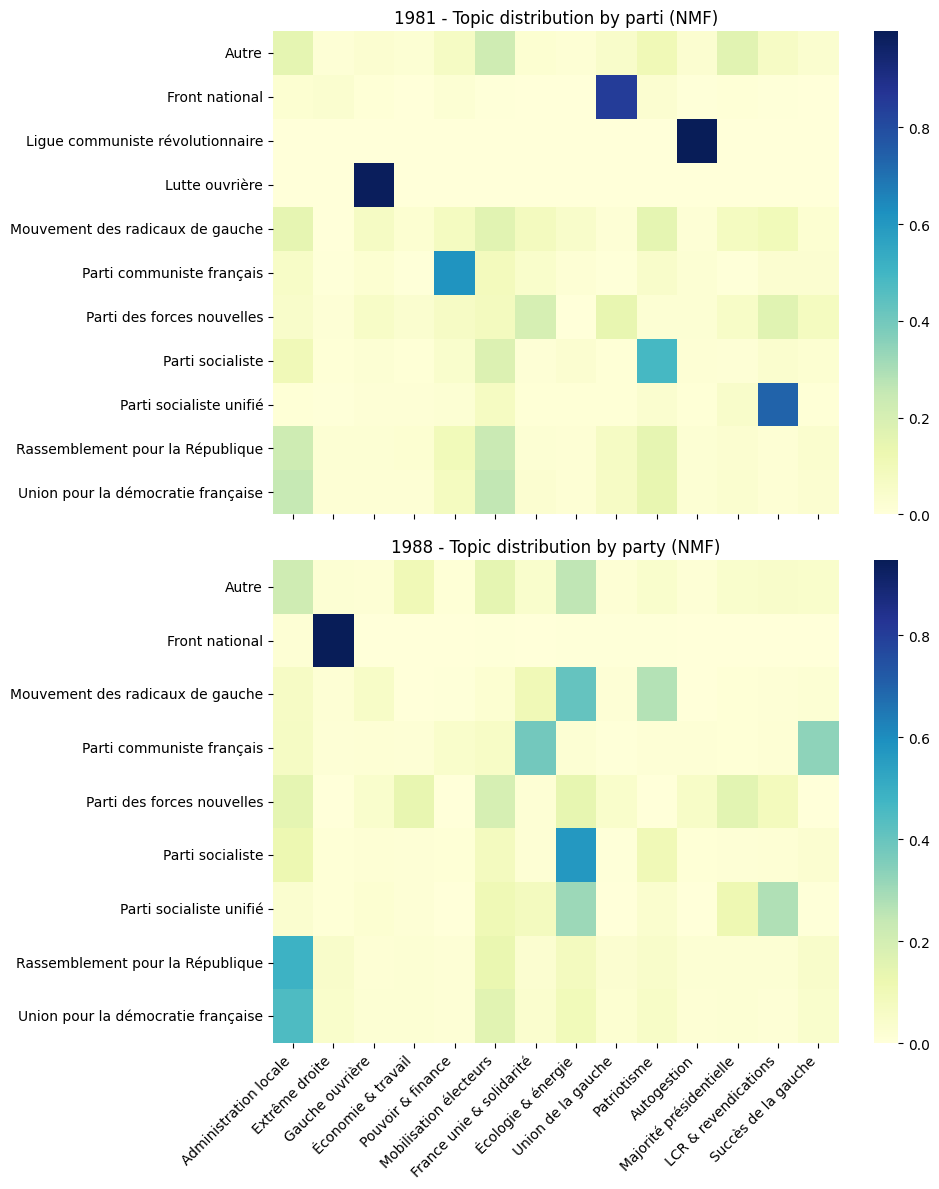

In [ ]:
n_topics = 14
ngram_range = (1, 1)

topic_titles = [
    "Administration locale",
    "Extrême droite",
    "Gauche ouvrière",                
    "Économie & travail",      
    "Pouvoir & finance",       
    "Mobilisation électeurs",
    "France unie & solidarité",     
    "Écologie & énergie",
    "Union de la gauche",           
    "Patriotisme",             
    "Autogestion",       
    "Majorité présidentielle",        
    "LCR & revendications",
    "Succès de la gauche" 
]

# =========================
# TF-IDF
# =========================
vectorizer = TfidfVectorizer(
    stop_words=STOPWORDS,
    ngram_range=ngram_range,
    min_df=0.005,
    max_df=0.7
)

X = vectorizer.fit_transform(docs)
feature_names = vectorizer.get_feature_names_out()

# NMF
nmf_model = NMF(
    n_components=n_topics,
    random_state=42,
    init="nndsvd"
)

W = nmf_model.fit_transform(X)
W = W / W.sum(axis=1, keepdims=True)

# Print topics
def print_topics(model, feature_names, topk=10):
    for i, topic in enumerate(model.components_):
        top_words = [feature_names[j] for j in topic.argsort()[-topk:][::-1]]
        print(f"{topic_titles[i]} {' | '.join(top_words)}")

print("\n===== TOPICS =====")
print_topics(nmf_model, feature_names)

# DATAFRAME
df2 = pd.DataFrame(W, columns=[f"topic_{i}" for i in range(n_topics)])
df2["parti"] = partis
df2["annee"] = annees  # ⚠️ important : 1981 / 1988

# =========================
# 2️⃣ DISTRIBUTION PAR PARTI ET PAR ANNÉE
# =========================
topic_parti_annee = df2.groupby(["annee", "parti"]).mean()

topic_81 = topic_parti_annee.loc[1981]
topic_88 = topic_parti_annee.loc[1988]

# =========================
# 3️⃣ HEATMAPS 1981 vs 1988
# =========================
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# 1981
sns.heatmap(topic_81, cmap="YlGnBu", ax=axes[0])
axes[0].set_title("1981 - Topic distribution by parti (NMF)")
axes[0].set_ylabel(None)

# 1988
sns.heatmap(topic_88, cmap="YlGnBu", ax=axes[1])
axes[1].set_title("1988 - Topic distribution by party (NMF)")
axes[1].set_ylabel(None)
axes[1].set_xticklabels(topic_titles, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("nmf_results.png",dpi=300)
plt.show()

## 5. LDA

### 5.1 LDA Grid search

In [ ]:
tokenized_docs = [doc.split() for doc in docs]  # liste de listes de tokens
dictionary = Dictionary(tokenized_docs)

# Coherence
def compute_coherence(topics):
    cm = CoherenceModel(
        topics=topics,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    return cm.get_coherence()

def compute_topic_diversity(topics, topk=10):
    all_words = [word for topic in topics for word in topic[:topk]]
    return len(set(all_words)) / len(all_words) if all_words else 0

def get_lda_topics(lda_model, feature_names, topk=10):
    topics = []
    for topic_weights in lda_model.components_:
        idx = topic_weights.argsort()[-topk:][::-1]
        topics.append([feature_names[i] for i in idx])
    return topics

# ==== Paramètres à tester ====
search_params = {
    "n_components": range(8,20),   # nombre de topics
    "max_iter": [100]                   # nombre d'itérations
}

ngram_range_list = [(1,1), (1,2)]

results = []
models = {}

# ==== Grid search ====
for n_topics, ngram_range in product(search_params["n_components"], ngram_range_list):
    
    # CountVectorizer
    vectorizer = CountVectorizer(
        stop_words=STOPWORDS,
        ngram_range=ngram_range,
        min_df=0.005,
        max_df=0.7
    )
    X = vectorizer.fit_transform(docs)
    feature_names = vectorizer.get_feature_names_out()
    
    # LDA
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        max_iter=100,
        random_state=42,
        learning_method="online"
    )
    lda.fit(X)
    
    # Topics
    topics = get_lda_topics(lda, feature_names)
    
    # Metrics
    coh = compute_coherence(topics)
    div = compute_topic_diversity(topics)
    score = coh * div
    
    # Stockage
    key = (n_topics, ngram_range)
    models[key] = (lda, vectorizer)
    
    results.append({
        "n_topics": n_topics,
        "ngram_range": ngram_range,
        "coherence": coh,
        "diversity": div,
        "score": score
    })
    
    print(f"n_topics={n_topics}, ngram={ngram_range} | coh={coh:.4f}, div={div:.4f}, score={score:.4f}")

# ==== Résultats ====
df_grid = pd.DataFrame(results).sort_values("score", ascending=False).reset_index(drop=True)
print("\nTop modèles :")
print(df_grid)

n_topics=8, ngram=(1, 1) | coh=0.4450, div=0.7500, score=0.3337
n_topics=8, ngram=(1, 2) | coh=0.4737, div=0.7000, score=0.3316
n_topics=9, ngram=(1, 1) | coh=0.4871, div=0.7111, score=0.3464
n_topics=9, ngram=(1, 2) | coh=0.4873, div=0.6889, score=0.3357
n_topics=10, ngram=(1, 1) | coh=0.5013, div=0.7200, score=0.3609
n_topics=10, ngram=(1, 2) | coh=0.4989, div=0.6800, score=0.3392
n_topics=11, ngram=(1, 1) | coh=0.4604, div=0.7182, score=0.3306
n_topics=11, ngram=(1, 2) | coh=0.5084, div=0.7364, score=0.3744
n_topics=12, ngram=(1, 1) | coh=0.4500, div=0.6917, score=0.3113
n_topics=12, ngram=(1, 2) | coh=0.5091, div=0.7000, score=0.3564
n_topics=13, ngram=(1, 1) | coh=0.4853, div=0.7077, score=0.3435
n_topics=13, ngram=(1, 2) | coh=0.4824, div=0.7154, score=0.3451
n_topics=14, ngram=(1, 1) | coh=0.4531, div=0.7286, score=0.3301
n_topics=14, ngram=(1, 2) | coh=0.4717, div=0.7000, score=0.3302
n_topics=15, ngram=(1, 1) | coh=0.4509, div=0.7000, score=0.3157
n_topics=15, ngram=(1, 2) | c

### 5.2 LDA model

In [ ]:
# Parameters
n_topics = 13
ngram_range = (1, 2)

# =========================
# VECTORIZATION (Count)
# =========================
vectorizer = CountVectorizer(
    stop_words=STOPWORDS,
    ngram_range=ngram_range,
    min_df=0.005,
    max_df=0.7
)

X = vectorizer.fit_transform(docs)
feature_names = vectorizer.get_feature_names_out()

# LDA
lda = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=100,
    random_state=42,
    learning_method="online"
)

W = lda.fit_transform(X)   
H = lda.components_      

# Topics
def print_topics(H, feature_names, topk=10):
    for i, topic in enumerate(H):
        top_words = [feature_names[j] for j in topic.argsort()[-topk:][::-1]]
        print(f"Topic {i}: {' | '.join(top_words)}")

print("\n===== TOPICS =====")
print_topics(H, feature_names)



===== TOPICS =====
Topic 0: majorité | mitterrand | françois | françois mitterrand | socialiste | président | mai | république | unie | donner
Topic 1: gauche | mitterrand | lutte | falloir | travailleur | député | majorité | gouvernement | homme | même
Topic 2: liberté | national | public | front | enseignement | majorité | patrie | devoir | populaire | battre
Topic 3: nucléaire | écologiste | gauche | devoir | énergie | falloir | femme | travail | vie | populaire
Topic 4: communiste | gauche | parti | parti communiste | changement | majorité | union | monsieur | voix | gouvernement
Topic 5: national | vote | front national | député | avenir | électeur | front | conviction | liste | confiance
Topic 6: falloir | réussir | blée | assem | assem blée | majorité | blée national | victoire | place | communiste
Topic 7: liberté | socialiste | majorité | union | 14 | 1981 | société | vouloir | national | 14 juin
Topic 8: accepter | europe | grand | pouvoir accepter | celer | financier | temp

In [ ]:
topic_titles_lda = [
    "Socialist Majority",     
    "Left-wing Politics",     
    "Liberty & Nationalism",   
    "Ecology & Energy",        
    "Communist Politics",      
    "National Front",         
    "Political Success / Victory", 
    "Socialist Agenda 1981",   
    "Europe & Power",          
    "Economic & Labour Rights",
    "Workers & Communist Movements", 
    "RPR & Right-wing",        
    "Local Governance / Duties"
]

In [8]:
partis = df["parti"]
annees = df["year"]    

In [27]:
topic_titles = ['Majorité présidentielle',
 'Dynamique de gauche',
 'Patriotisme',
 'Ecologie',
 'Radicalité de gauche',
 'Extrême droite',
 'Action parlementaire',
 'Union de la gauche',
 'Europe',
 'Economie',
 'Travail',
 'Droite',
 'Administration locale']

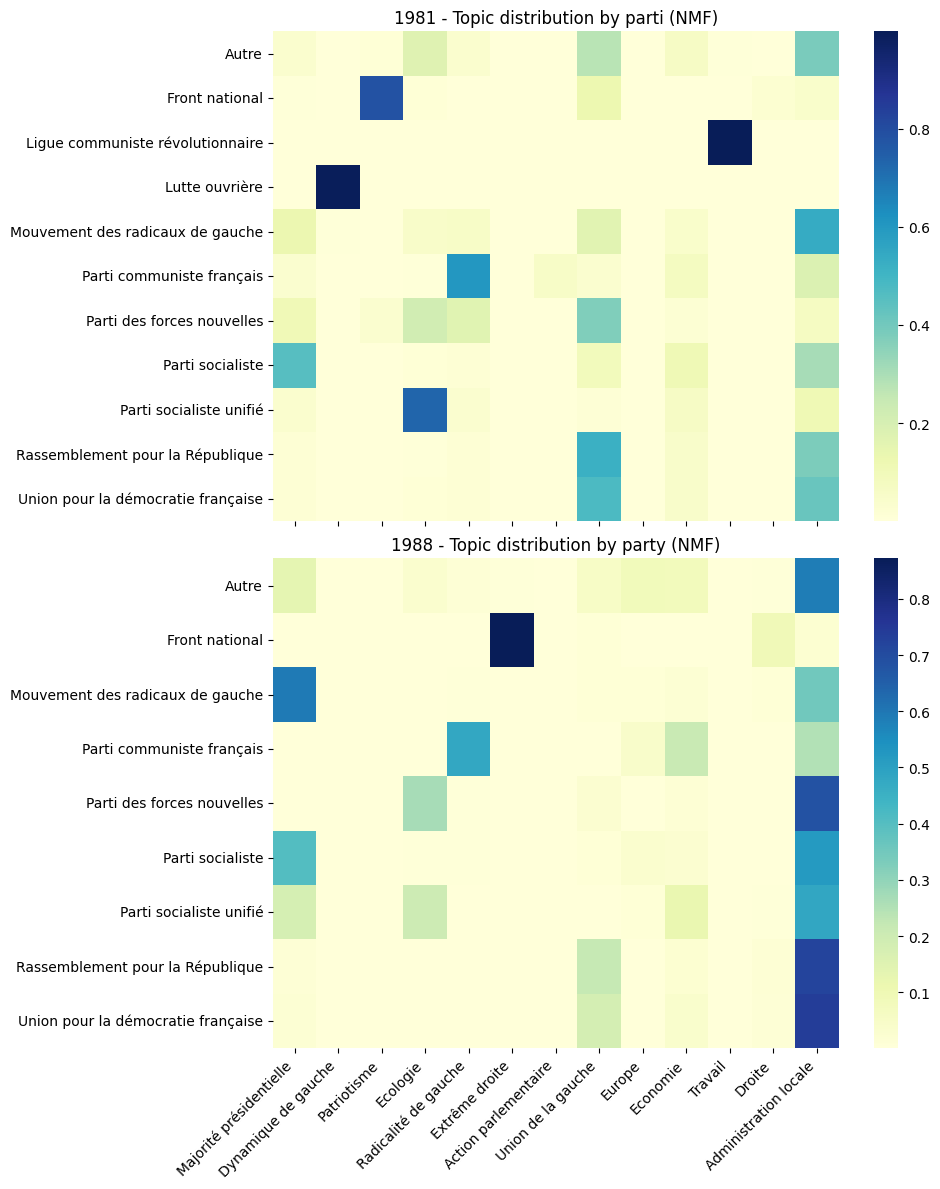

In [ ]:
df2 = pd.DataFrame(W, columns=[f"topic_{i}" for i in range(n_topics)])
df2["parti"] = partis
df2["annee"] = annees  # ⚠️ important : 1981 / 1988

topic_parti_annee = df2.groupby(["annee", "parti"]).mean()

topic_81 = topic_parti_annee.loc[1981]
topic_88 = topic_parti_annee.loc[1988]

# 3 HEATMAPS 1981 vs 1988
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# 1981
sns.heatmap(topic_81, cmap="YlGnBu", ax=axes[0])
axes[0].set_title("1981 - Topic distribution by parti (NMF)")
axes[0].set_ylabel(None)

# 1988
sns.heatmap(topic_88, cmap="YlGnBu", ax=axes[1])
axes[1].set_title("1988 - Topic distribution by party (NMF)")
axes[1].set_ylabel(None)
axes[1].set_xticklabels(topic_titles, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("lda_results.png",dpi=300)
plt.show()